In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r"C:\Users\ansar\Downloads\Solar Energy.csv", low_memory=False)


print("Shape:", df.shape)
print("\nColumns:\n", df.columns)


df.head()

Shape: (218115, 17)

Columns:
 Index(['Data Through Date', 'Project ID', 'Interconnection Date', 'Utility',
       'City/Town', 'County', 'Zip', 'Division', 'Substation', 'Circuit ID',
       'Developer', 'Metering Method', 'Estimated PV System Size (kWdc)',
       'PV System Size (kWac)', 'Estimated Annual PV Energy Production (kWh)',
       'Energy Storage System Size (kWac)', 'Number of Projects'],
      dtype='object')


,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


In [3]:
# Data types
df.info()

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("\nMissing Values:\n", missing)

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218115 entries, 0 to 218114
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Data Through Date                            218115 non-null  object 
 1   Project ID                                   218112 non-null  object 
 2   Interconnection Date                         218115 non-null  object 
 3   Utility                                      218115 non-null  object 
 4   City/Town                                    218057 non-null  object 
 5   County                                       218115 non-null  object 
 6   Zip                                          218019 non-null  float64
 7   Division                                     132881 non-null  object 
 8   Substation                                   138171 non-null  object 
 9   Circuit ID                                   218085 non-nul

In [ ]:
# Make a copy
df_clean = df.copy()

# 1. Drop irrelevant columns
df_clean.drop(columns=[
    "Project ID",
    "Data Through Date",
    "Energy Storage System Size (kWac)",
    "Division",
    "Substation"
], inplace=True)

# Fill categorical with "Unknown"
categorical_fill = ["Developer", "Metering Method", "City/Town"]
for col in categorical_fill:
    df_clean[col] = df_clean[col].fillna("Unknown")


df_clean["Zip"] = df_clean["Zip"].fillna(df_clean["Zip"].mode()[0])


df_clean.dropna(subset=["Circuit ID"], inplace=True)
print("Shape after cleaning:", df_clean.shape)

print("\nRemaining missing values:\n")
print(df_clean.isnull().sum())

Shape after cleaning: (218085, 12)

Remaining missing values:

Interconnection Date                           0
Utility                                        0
City/Town                                      0
County                                         0
Zip                                            0
Circuit ID                                     0
Developer                                      0
Metering Method                                0
Estimated PV System Size (kWdc)                0
PV System Size (kWac)                          0
Estimated Annual PV Energy Production (kWh)    0
Number of Projects                             0
dtype: int64


In [ ]:

df_clean["Interconnection Date"] = pd.to_datetime(df_clean["Interconnection Date"], errors='coerce')

df_clean["Year"] = df_clean["Interconnection Date"].dt.year
df_clean["Month"] = df_clean["Interconnection Date"].dt.month

df_clean.drop(columns=["Interconnection Date"], inplace=True)

df_clean.head()

,Utility,City/Town,County,Zip,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Number of Projects,Year,Month
0,Con Ed,Richmond Hill,Queens,11418.0,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,1,2023,12
1,Con Ed,Bronx,Bronx,10473.0,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,1,2023,12
2,Con Ed,Brooklyn,Kings,11225.0,4B08,SUNCO,NM,3.05,2.61,3585,1,2023,12
3,Con Ed,Brooklyn,Kings,11236.0,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,1,2023,12
4,Con Ed,Springfield Gardens,Queens,11413.0,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,1,2023,12


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

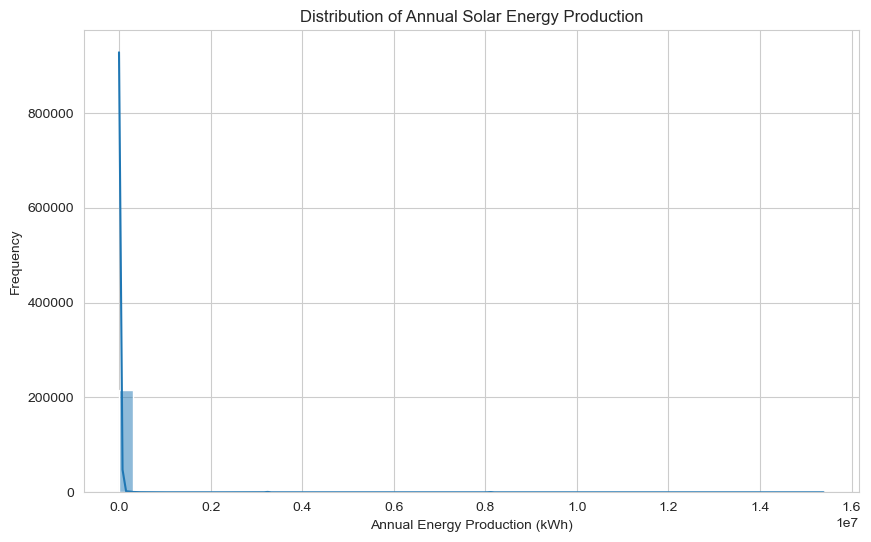

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_clean["Estimated Annual PV Energy Production (kWh)"],
    bins=50,
    kde=True
)

plt.title("Distribution of Annual Solar Energy Production")
plt.xlabel("Annual Energy Production (kWh)")
plt.ylabel("Frequency")

plt.show()

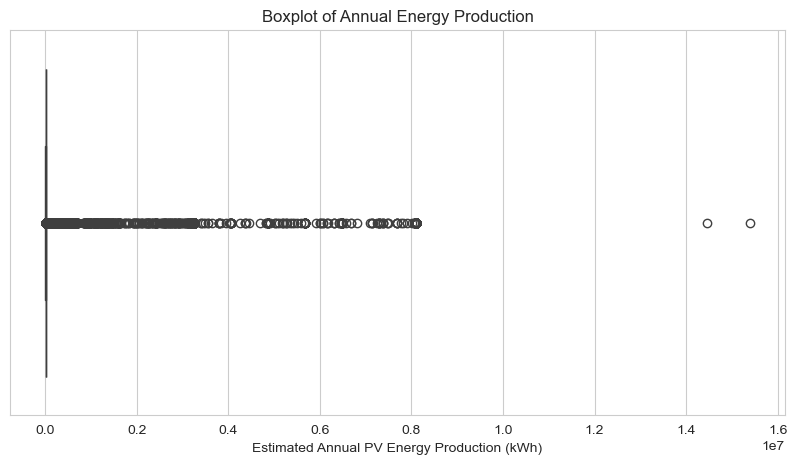

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df_clean["Estimated Annual PV Energy Production (kWh)"]
)

plt.title("Boxplot of Annual Energy Production")

plt.show()

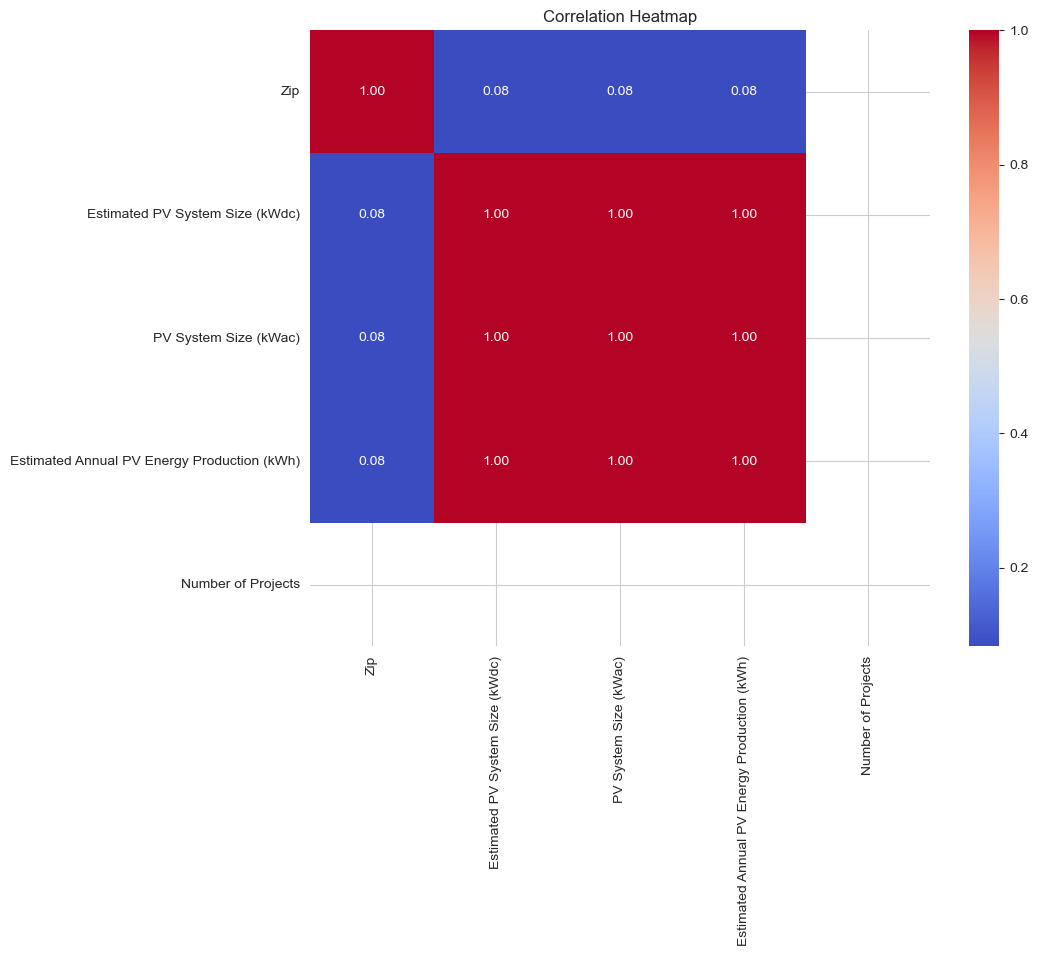

In [29]:
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

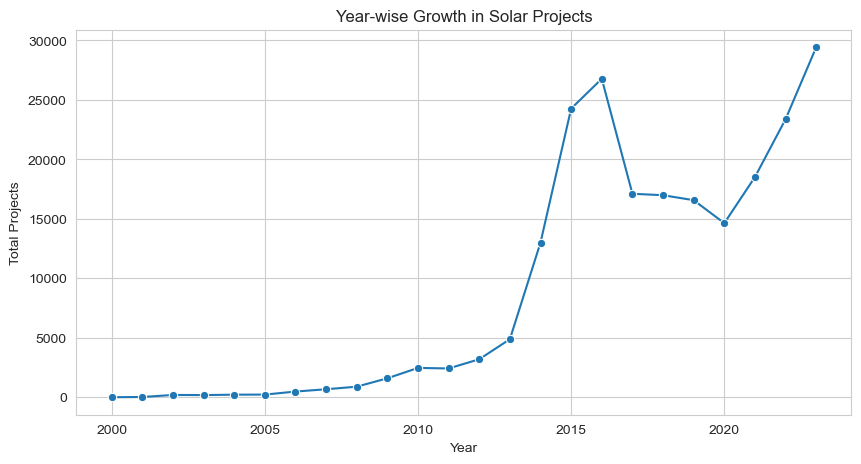

In [30]:
yearly_projects = (
    df_clean.groupby("Year")
    ["Number of Projects"]
    .sum()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=yearly_projects.index,
    y=yearly_projects.values,
    marker='o'
)

plt.title("Year-wise Growth in Solar Projects")
plt.xlabel("Year")
plt.ylabel("Total Projects")

plt.show()

In [ ]:

y = df_clean["Estimated Annual PV Energy Production (kWh)"]

X = df_clean.drop(columns=["Estimated Annual PV Energy Production (kWh)"])

print("Feature shape:", X.shape)

Feature shape: (218085, 12)


In [7]:
# Categorical & Numerical columns
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:\n", cat_cols)
print("\nNumerical Columns:\n", num_cols)

Categorical Columns:
 Index(['Utility', 'City/Town', 'County', 'Circuit ID', 'Developer',
       'Metering Method'],
      dtype='object')

Numerical Columns:
 Index(['Zip', 'Estimated PV System Size (kWdc)', 'PV System Size (kWac)',
       'Number of Projects', 'Year', 'Month'],
      dtype='object')


In [ ]:

df_sample = df_clean.sample(n=50000, random_state=42)

X_sample = df_sample.drop(columns=["Estimated Annual PV Energy Production (kWh)"])
y_sample = df_sample["Estimated Annual PV Energy Production (kWh)"]

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50,max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"RMSE": rmse, "R2": r2}
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)


Linear Regression
RMSE: 15.012537272199985
R2 Score: 0.9999999979364159

Random Forest
RMSE: 3211.761570083585
R2 Score: 0.999905550305202

Gradient Boosting
RMSE: 2277.5809237209996
R2 Score: 0.9999525035011183


In [12]:
drop_cols = [
    "Estimated PV System Size (kWdc)",
    "PV System Size (kWac)"
]

X_realistic = X.drop(columns=drop_cols)

In [ ]:
# New dataset
X_real = X.drop(columns=[
    "Estimated PV System Size (kWdc)",
    "PV System Size (kWac)"
])


from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real, y, test_size=0.2, random_state=42
)

cat_cols_r = X_real.select_dtypes(include=["object"]).columns
num_cols_r = X_real.select_dtypes(exclude=["object"]).columns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_r = ColumnTransformer([
    ("num", StandardScaler(), num_cols_r),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols_r)
])

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

pipeline_r = Pipeline([
    ("preprocessor", preprocessor_r),
    ("model", GradientBoostingRegressor())
])

# Train
pipeline_r.fit(X_train_r, y_train_r)

# Predict
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_r = pipeline_r.predict(X_test_r)

rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2_r = r2_score(y_test_r, y_pred_r)

print("Realistic Model Performance")
print("RMSE:", rmse_r)
print("R2 Score:", r2_r)

Realistic Model Performance
RMSE: 159591.60005929484
R2 Score: 0.7642920826758817


In [ ]:
# Smaller sample for tuning
df_tune = df_clean.sample(n=30000, random_state=42)

X_tune = df_tune.drop(columns=[
    "Estimated Annual PV Energy Production (kWh)",
    "Estimated PV System Size (kWdc)",
    "PV System Size (kWac)"
])

y_tune = df_tune["Estimated Annual PV Energy Production (kWh)"]

from sklearn.model_selection import train_test_split

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tune, y_tune, test_size=0.2, random_state=42
)

cat_cols_t = X_tune.select_dtypes(include=["object"]).columns
num_cols_t = X_tune.select_dtypes(exclude=["object"]).columns

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_t = ColumnTransformer([
    ("num", StandardScaler(), num_cols_t),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols_t)
])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_t),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [30, 50],
    "model__max_depth": [10, 15],
    "model__min_samples_split": [2, 5]
}

# Random Search
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    n_iter=3,
    cv=2,
    scoring="r2",
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train_t, y_train_t)

print("Best Parameters:")
print(rf_search.best_params_)

Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best Parameters:
{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__max_depth': 15}


In [18]:
# Best model
best_rf = rf_search.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test_t)

# Metrics
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(y_test_t, y_pred_rf))
r2_rf = r2_score(y_test_t, y_pred_rf)

print("\nTuned Random Forest")
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)


Tuned Random Forest
RMSE: 265832.9645532094
R2 Score: 0.5241793341689733


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

# Final pipeline
final_pipeline = Pipeline([
    ("preprocessor", preprocessor_r),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])

# Train final model
final_pipeline.fit(X_train_r, y_train_r)

print("Final model trained successfully!")

Final model trained successfully!


In [20]:
# Predictions
y_pred_final = final_pipeline.predict(X_test_r)

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_final))
mae = mean_absolute_error(y_test_r, y_pred_final)
r2 = r2_score(y_test_r, y_pred_final)

print("FINAL MODEL PERFORMANCE")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

FINAL MODEL PERFORMANCE
RMSE: 148607.56618123953
MAE: 15700.873577193333
R2 Score: 0.7956211478229669


In [ ]:

sample_input = pd.DataFrame({
    "Utility": ["National Grid"],
    "City/Town": ["Springfield"],
    "County": ["Hampden"],
    "Zip": [1103],
    "Circuit ID": ["CIR123"],
    "Developer": ["Unknown"],
    "Metering Method": ["Net Metering"],
    "Number of Projects": [1],
    "Year": [2026],
    "Month": [6]
})

# Predict
prediction = final_pipeline.predict(sample_input)

print("Predicted Annual Energy Production (kWh):")
print(prediction[0])

Predicted Annual Energy Production (kWh):
466395.47954599885


In [31]:
# Get trained model
model = final_pipeline.named_steps["model"]

# Get encoded feature names
encoded_cat_features = final_pipeline.named_steps[
    "preprocessor"
].named_transformers_["cat"].get_feature_names_out(cat_cols_r)

# Combine all feature names
all_features = list(num_cols_r) + list(encoded_cat_features)

importance = model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importance
})


importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                                                 Feature  Importance
11526                                Metering Method_CDG    0.361690
0                                                    Zip    0.321084
2                                                   Year    0.071740
11528                                 Metering Method_NM    0.024861
2943                                       County_Orange    0.018542
10765                            Developer_Renovus Solar    0.011113
5                                         Utility_Con Ed    0.011043
10790  Developer_Robert Tompkins (Borrego Solar Syste...    0.009742
2400                                  City/Town_Shoreham    0.009127
9344                             Developer_Ameresco Inc.    0.007797
10537                                   Developer_Nexamp    0.007498
11184                         Developer_Sybac Solar_ LLC    0.007127
8419                                   Circuit ID_8DR425    0.006202
2539                              

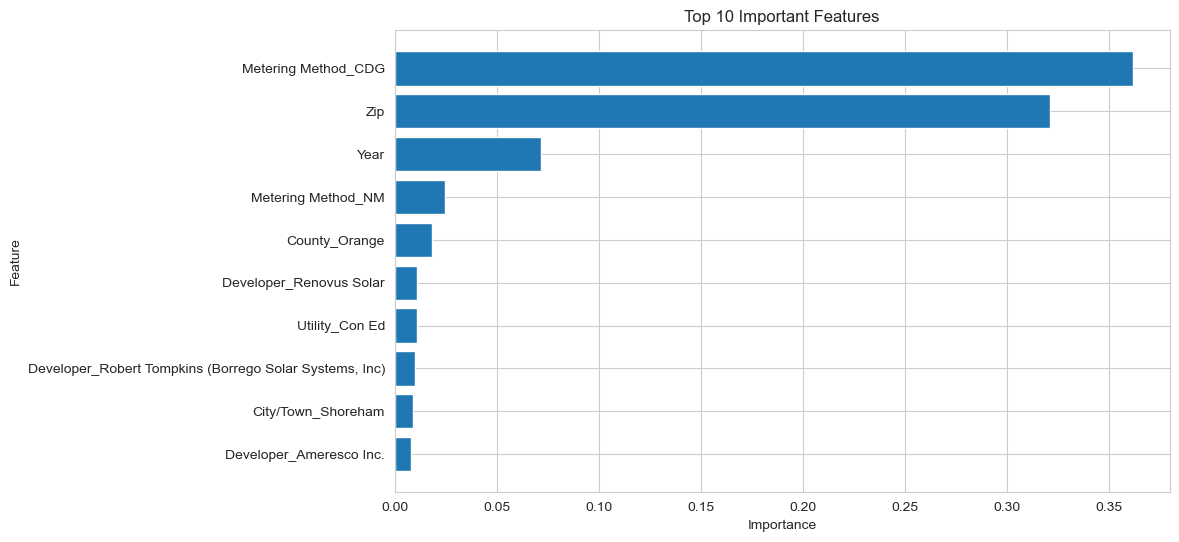

In [32]:
import matplotlib.pyplot as plt

# Top 10
top10 = importance_df.head(10)

# Plot
plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [24]:
import joblib

# Save model
joblib.dump(final_pipeline, "solar_energy_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
